# BridgeRNA contextual gene-network utility

This is the scientist-facing record of a frozen layer-12 contextual-gene graph
benchmark. Edges denote contextual relationships—not causal regulation. Graph
parameters were fixed independently of RR1/RR3, and no encoder inference or
training occurs in this benchmark.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path('results')
prov = json.loads((ROOT/'summary/provenance.json').read_text())
display(pd.Series(prov, name='value').to_frame())

,value
checkpoint,r7hnr92k
encoder,frozen; no inference in this benchmark
genes,15165
layer,12
primary_graph,cosine kNN k=10 union symmetrized weighted
sensitivity_k,"[5, 20]"
source_graph_cache,benchmarks/frozen_sample_embedding_readout/wor...
communities,not used as primary due prior poor reproducibi...
claim_discipline,"contextual relationships, not causal/regulator..."
limitations,[Top-k graph cache censors non-neighbor contex...


## 1. Known functional relationships

Positive pairs share Hallmark, GO Biological Process, or Reactome membership.
Negatives are matched on expression mean and graph degree. BridgeRNA is scored
by occurrence-weighted contextual Top-10 edge strength over a study-diverse
cohort; raw expression correlation is the conventional comparator. Non-neighbor
pairs score zero because the cache intentionally retains only Top-20 neighbors.

source,method,pairs,positive_pairs,AUROC,AUPRC,top_1pct_enrichment,top_5pct_enrichment,top_10pct_enrichment
Hallmark,BridgeRNA contextual graph,1620,810,0.544,0.537,1.50×,1.51×,1.43×
Hallmark,Raw expression correlation,1620,810,0.575,0.584,1.50×,1.33×,1.41×
GO BP,BridgeRNA contextual graph,19496,9748,0.512,0.510,1.35×,1.21×,0.70×
GO BP,Raw expression correlation,19496,9748,0.520,0.526,1.29×,1.15×,1.14×
Reactome,BridgeRNA contextual graph,17431,8716,0.511,0.510,1.29×,1.21×,0.69×
Reactome,Raw expression correlation,17431,8716,0.521,0.530,1.40×,1.19×,1.12×


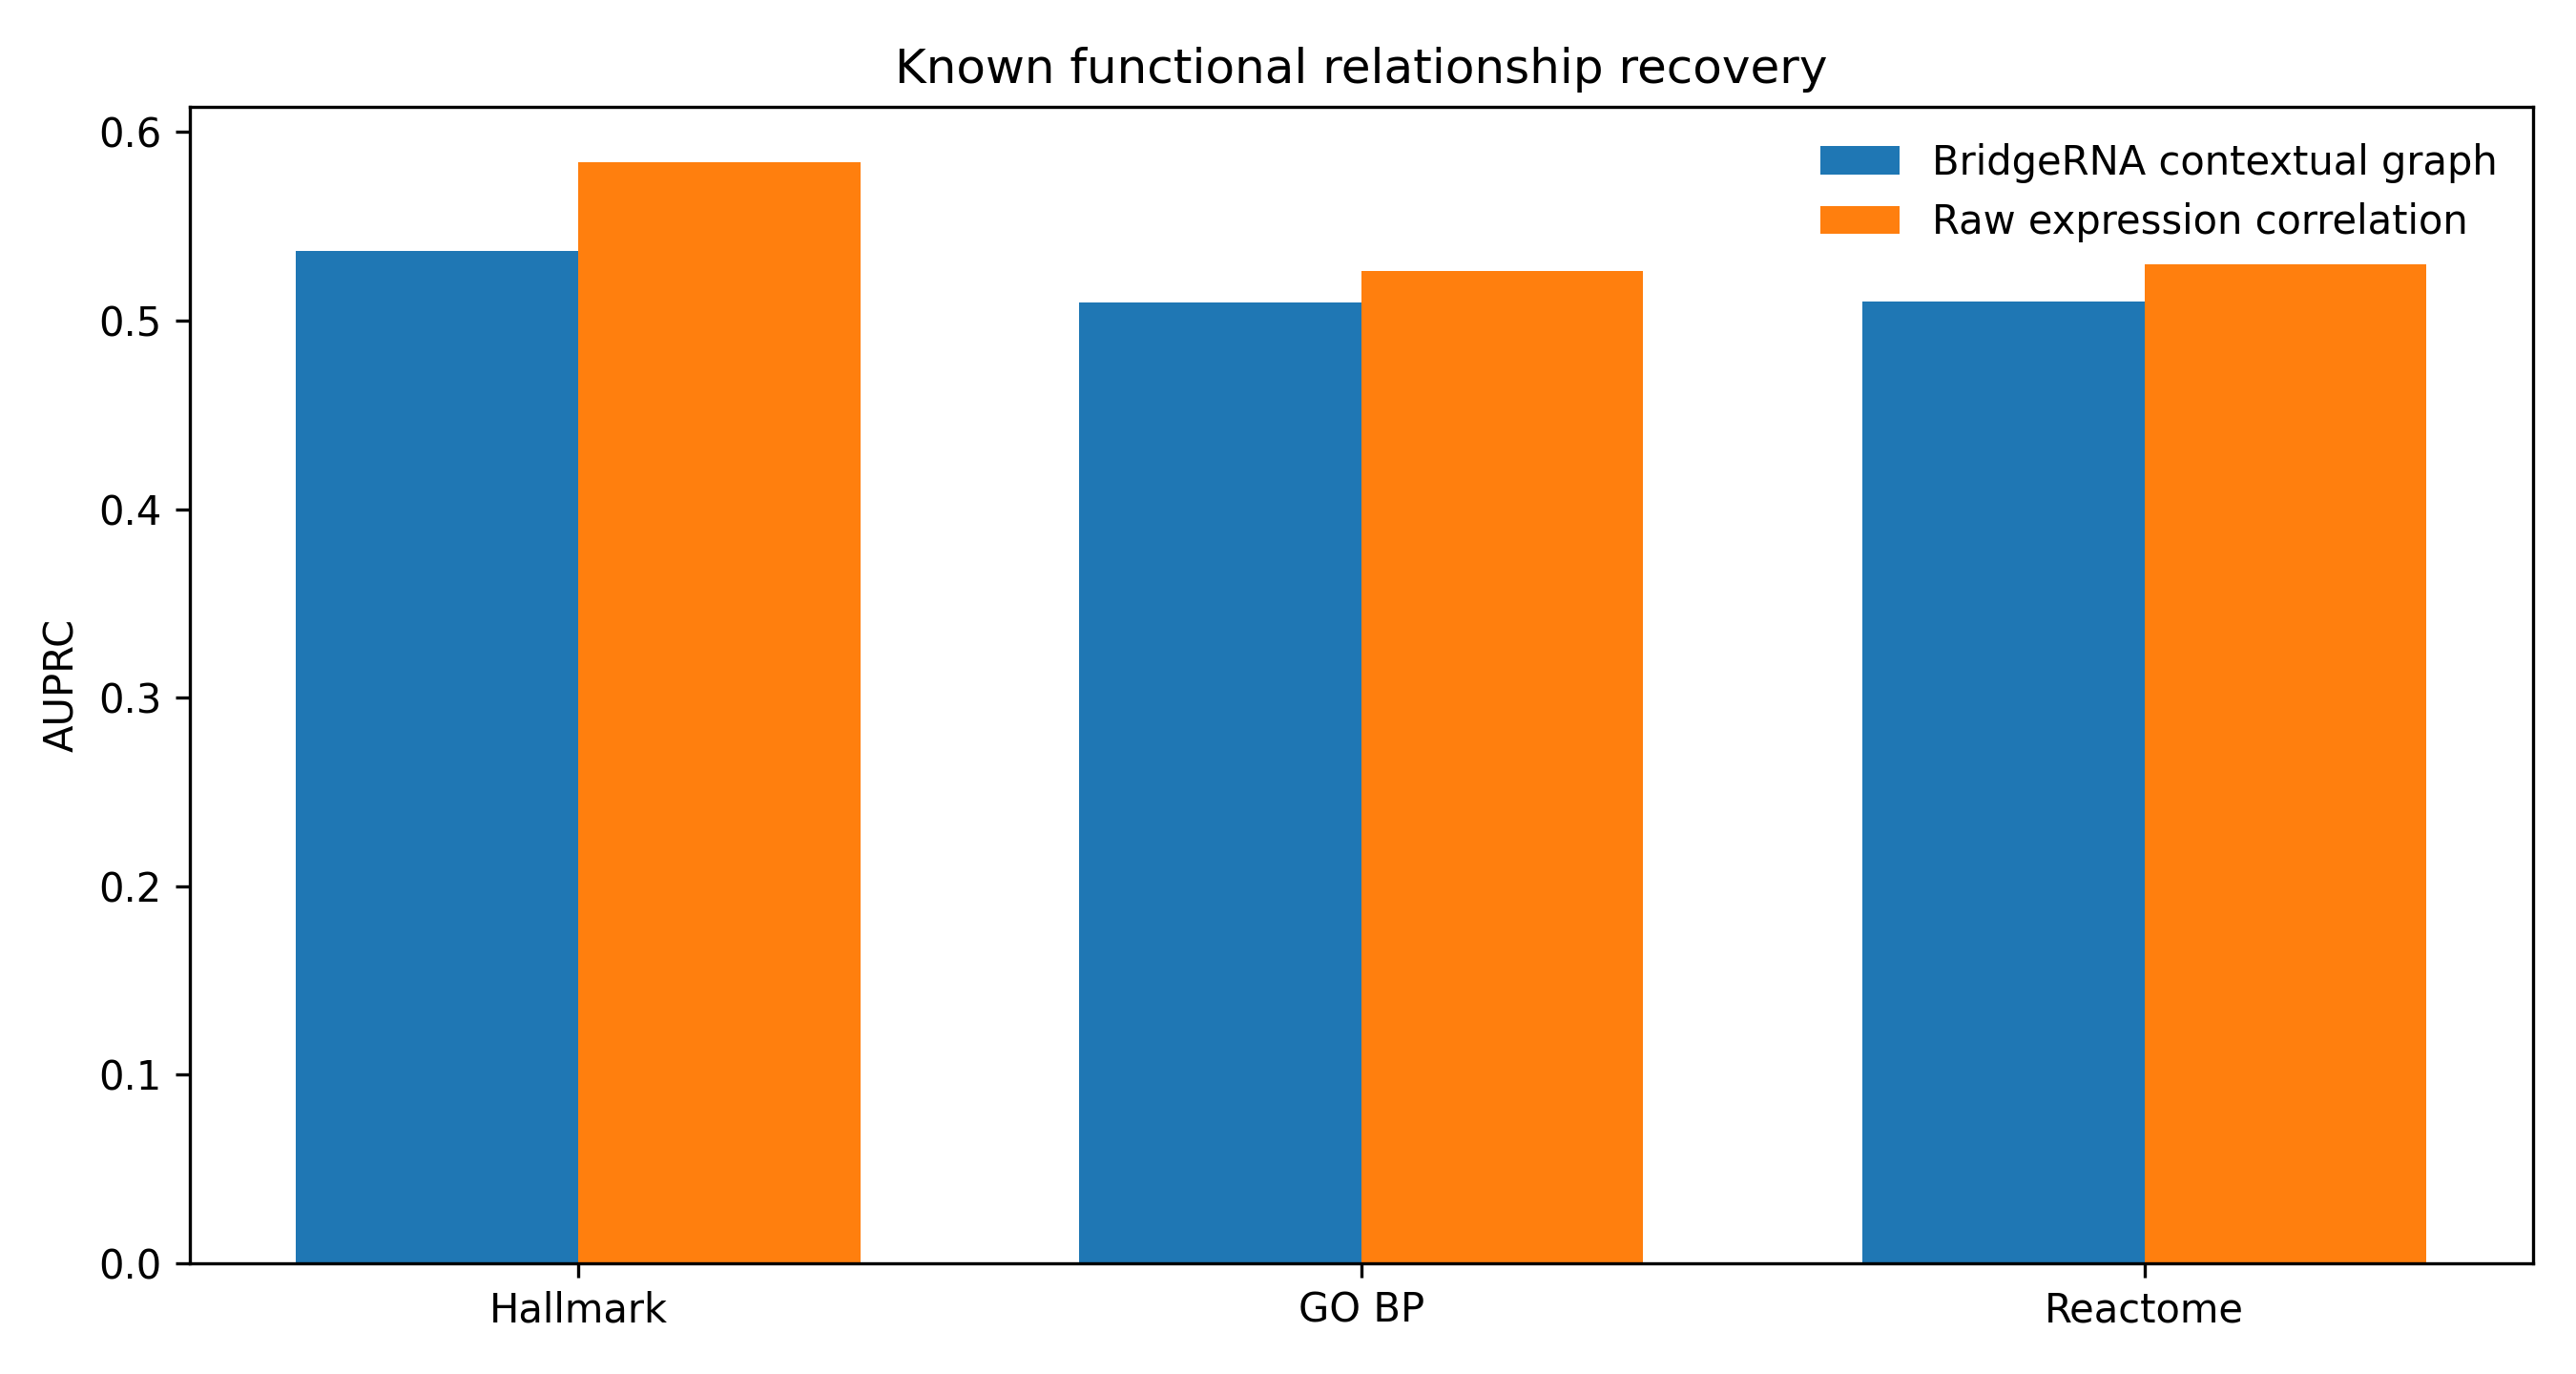

In [2]:
relationship = pd.read_csv(ROOT/'relationship_recovery/relationship_recovery_summary.csv')
display(relationship.style.format({'AUROC':'{:.3f}','AUPRC':'{:.3f}','top_1pct_enrichment':'{:.2f}×','top_5pct_enrichment':'{:.2f}×','top_10pct_enrichment':'{:.2f}×'}).hide(axis='index'))
display(Image(filename=str(ROOT/'figures/relationship_recovery.png')))

## 2. Perturbation network rewiring

Each response is the mean treatment graph minus the mean control graph. Tables
expose gained/strengthened and lost/weakened contextual relationships, plus the
genes with greatest incident edge-weight turnover. Annotation follows—not
defines—the network calculation.

In [3]:
manifest = pd.read_csv(ROOT/'perturbation_rewiring/contrast_manifest.csv')
display(manifest)
for cohort in ['exercise','task3','tcell']:
    print(f'\n{cohort}: representative k=10 events')
    display(pd.read_csv(ROOT/f'perturbation_rewiring/{cohort}_top_edges_k10.csv').groupby('contrast_id').head(3))

,contrast_id,dataset,species,n_treatment,n_control
0,human_GSE108643,exercise,human,28,28
1,human_GSE151066,exercise,human,19,19
2,human_GSE71972,exercise,human,6,6
3,human_GSE86931,exercise,human,2,2
4,human_GSE87748,exercise,human,8,8
5,mouse_GSE126962,exercise,mouse,2,2
6,mouse_GSE132520,exercise,mouse,4,4
7,mouse_GSE97718,exercise,mouse,4,4
8,C01__OSD-137__RR3__39-day,spaceflight,mouse,2,2
9,C02__OSD-137__RR3__40-day,spaceflight,mouse,3,2



exercise: representative k=10 events


,contrast_id,k,rank,gene_A,gene_B,delta_weight,change
0,human_GSE108643,10,1,MCAM,STING1,-0.713344,lost/weakened
1,human_GSE108643,10,2,PIK3R3,TNFRSF21,-0.698783,lost/weakened
2,human_GSE108643,10,3,LBH,TPM4,-0.694249,lost/weakened
20,human_GSE151066,10,1,NR4A2,REL,-0.757042,lost/weakened
21,human_GSE151066,10,2,ARL5B,NR4A2,-0.755114,lost/weakened
22,human_GSE151066,10,3,AMOTL2,KLF4,-0.754446,lost/weakened
40,human_GSE71972,10,1,SLCO2B1,SOX18,-0.782552,lost/weakened
41,human_GSE71972,10,2,CYTIP,LCP2,-0.781494,lost/weakened
42,human_GSE71972,10,3,MFNG,SOX18,-0.781413,lost/weakened
60,human_GSE86931,10,1,DCDC2,RASAL1,-0.794922,lost/weakened



task3: representative k=10 events


,contrast_id,k,rank,gene_A,gene_B,delta_weight,change
0,C01__OSD-137__RR3__39-day,10,1,ACTA1,TNNT3,0.777588,gained/strengthened
1,C01__OSD-137__RR3__39-day,10,2,POU4F2,PTPRZ1,0.775391,gained/strengthened
2,C01__OSD-137__RR3__39-day,10,3,GFRAL,PRDM12,0.772461,gained/strengthened
20,C02__OSD-137__RR3__40-day,10,1,PRDM12,TFAP2D,0.770345,gained/strengthened
21,C02__OSD-137__RR3__40-day,10,2,MYT1L,SEZ6L,-0.763428,lost/weakened
22,C02__OSD-137__RR3__40-day,10,3,FSTL4,TMEM59L,0.762695,gained/strengthened
40,C03__OSD-137__RR3__41-day,10,1,HMGB4,P3R3URF,-0.775635,lost/weakened
41,C03__OSD-137__RR3__41-day,10,2,ABCC8,NALF1,-0.770752,lost/weakened
42,C03__OSD-137__RR3__41-day,10,3,DIRAS1,PCSK1N,-0.769775,lost/weakened
60,C04__OSD-168__RR1-NASA__37-day,10,1,HES3,NTN5,-0.728857,lost/weakened



tcell: representative k=10 events


,contrast_id,k,rank,gene_A,gene_B,delta_weight,change
0,controlled_Tcell_Ribo_minus_PolyA,10,1,CD19,CXCR5,0.768286,gained/strengthened
1,controlled_Tcell_Ribo_minus_PolyA,10,2,DEFB110,XKR4,-0.740588,lost/weakened
2,controlled_Tcell_Ribo_minus_PolyA,10,3,GPR22,POU5F2,-0.737122,lost/weakened


## 3. Cross-study response conservation

Signed network-response cosine is calculated on the union of changed edges.
Established study groupings are retained and never selected from graph results.

,contrast_A,contrast_B,weighted_edge_response_cosine
165,C02__OSD-137__RR3__40-day,C06__OSD-168__RR3__40-day,0.335285
151,C01__OSD-137__RR3__39-day,C05__OSD-168__RR3__39-day,0.319309
1,human_GSE108643,human_GSE71972,0.272905
0,human_GSE108643,human_GSE151066,0.239893
22,human_GSE151066,human_GSE71972,0.224201
2,human_GSE108643,human_GSE86931,0.222258
191,C04__OSD-168__RR1-NASA__37-day,C09__OSD-245__RR6-ISS-T__not-reported,0.179855
232,C09__OSD-245__RR6-ISS-T__not-reported,C10__OSD-245__RR6-LAR__not-reported,0.169246
196,C04__OSD-168__RR1-NASA__37-day,C14__OSD-48__RR1-NASA__37-day,0.152470
23,human_GSE151066,human_GSE86931,0.112569


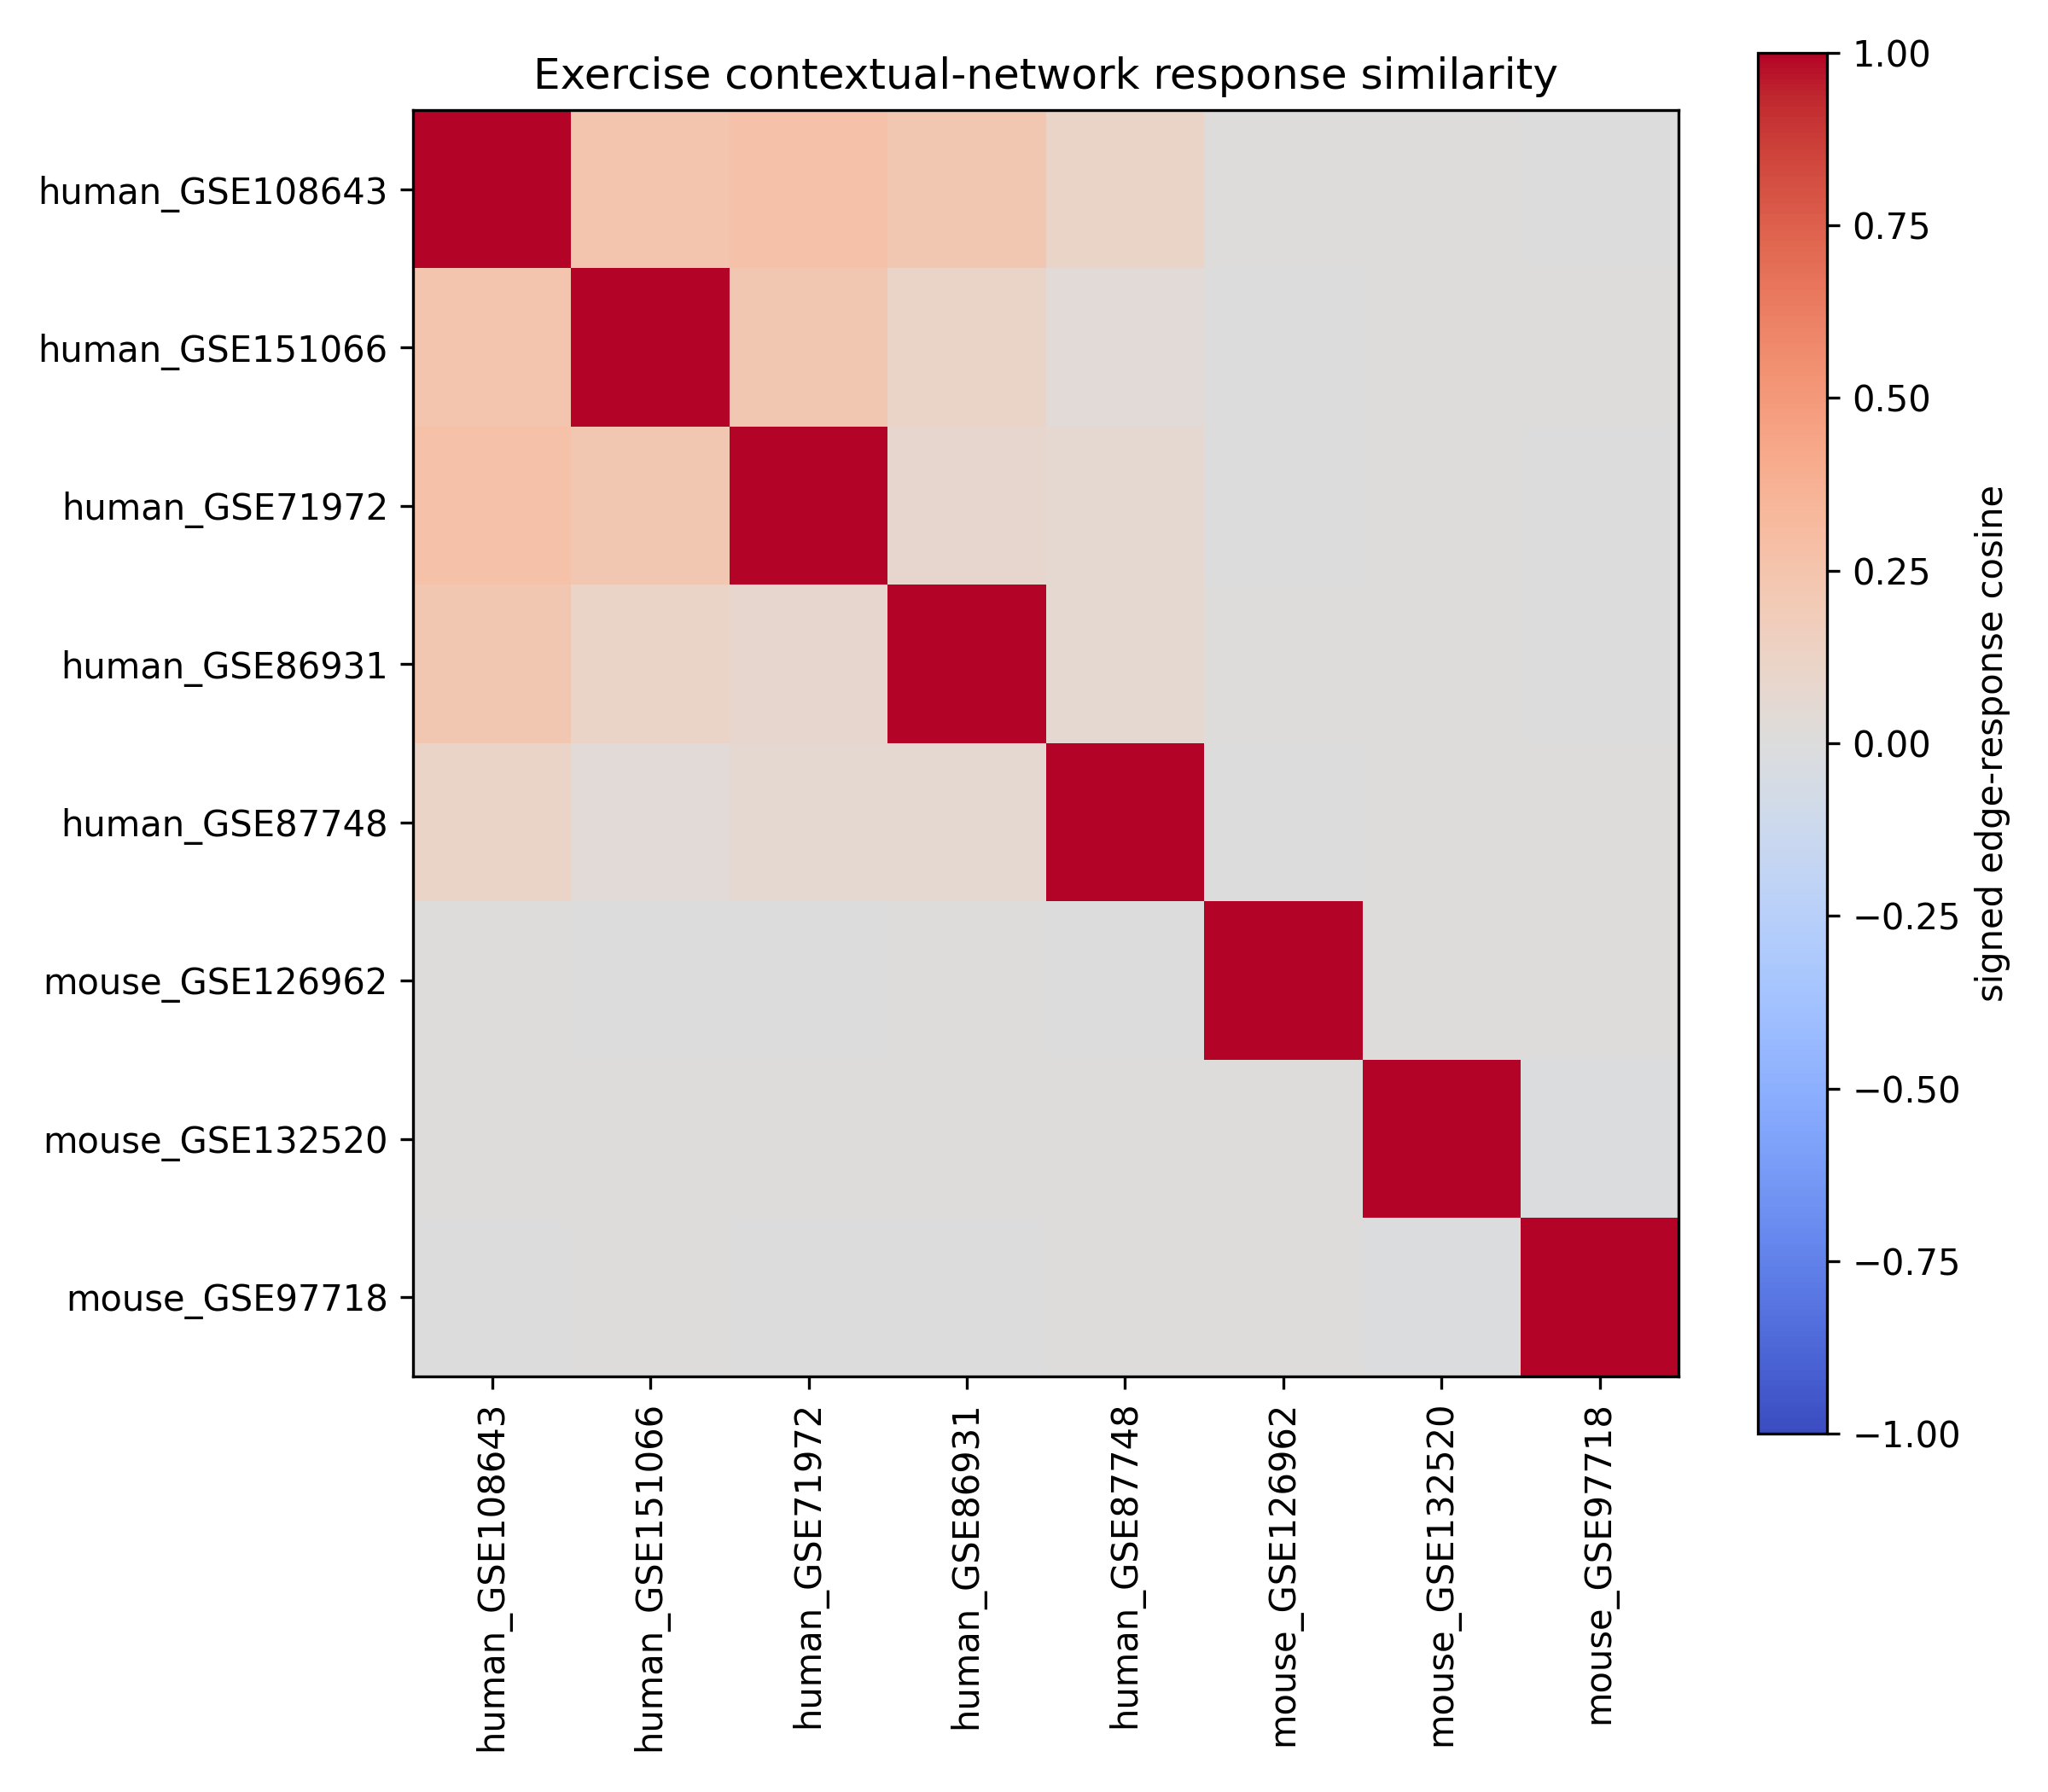

In [4]:
cross_study = pd.read_csv(ROOT/'cross_study/all_pair_graph_response_similarity.csv')
display(cross_study.sort_values('weighted_edge_response_cosine', ascending=False).head(20))
display(Image(filename=str(ROOT/'figures/exercise_response_similarity.png')))

## 4. Cross-species conservation

Human and mouse exercise graphs use the fixed one-to-one ortholog node order.
Every prespecified human×mouse study comparison is shown.

In [5]:
cross_species = pd.read_csv(ROOT/'cross_species/human_mouse_exercise_network_conservation.csv')
display(cross_species.sort_values('weighted_edge_response_cosine', ascending=False).style.format({'weighted_edge_response_cosine':'{:.3f}','top1000_edge_jaccard':'{:.3f}'}).hide(axis='index'))

human_contrast,mouse_contrast,weighted_edge_response_cosine,top1000_edge_jaccard
human_GSE151066,mouse_GSE132520,0.006,0.003
human_GSE108643,mouse_GSE132520,0.004,0.002
human_GSE86931,mouse_GSE132520,0.004,0.000
human_GSE87748,mouse_GSE132520,0.002,0.002
human_GSE108643,mouse_GSE126962,0.001,0.000
human_GSE71972,mouse_GSE132520,0.001,0.003
human_GSE86931,mouse_GSE126962,0.001,0.002
human_GSE87748,mouse_GSE97718,0.001,0.000
human_GSE151066,mouse_GSE97718,0.000,0.000
human_GSE71972,mouse_GSE97718,-0.000,0.001


## 5. Existing attribution and DE agreement

Graph-important genes are compared with saved IG and edgeR results. Neither is
recomputed. Older deletion panels use different rankings and are not presented
as graph-guided validation.

In [6]:
overlap = pd.read_csv(ROOT/'attribution_validation/graph_gene_ig_de_overlap.csv')
display(overlap.groupby('contrast_id').agg(top_graph_genes=('gene','size'), overlap_IG=('in_existing_IG_results','sum'), overlap_DE=('in_top100_DE_any_exercise_study','sum')).reset_index())
display(pd.read_csv(ROOT/'attribution_validation/deletion_status.csv'))

,contrast_id,top_graph_genes,overlap_IG,overlap_DE
0,human_GSE108643,20,1,0
1,human_GSE151066,20,4,0
2,human_GSE71972,20,1,0
3,human_GSE86931,20,0,0
4,human_GSE87748,20,1,0
5,mouse_GSE126962,20,0,0
6,mouse_GSE132520,20,3,0
7,mouse_GSE97718,20,0,0


,analysis,status,reason
0,graph-guided deletion,not_run,requires new frozen-model inference; no compat...


## 6. Decision and interpretation

The decision is derived from saved relationship-recovery results. Cross-study
and cross-species response comparisons remain exploratory given eight curated
exercise contrasts. Louvain communities are not promoted because prior
technical-pair community agreement was not discriminative.

In [7]:
decision = pd.read_csv(ROOT/'summary/decision_summary.csv')
display(decision)
display(relationship.pivot(index='source', columns='method', values=['AUROC','AUPRC']).style.format('{:.3f}'))

,decision,annotation_sources_contextual_AUPRC_above_raw,annotation_sources_total,graph_guided_deletion_run
0,MOSTLY COEXPRESSION RECAPITULATION,0,3,False


### Scientist-facing conclusion

This benchmark asks a question raw expression and PCA do not directly expose:
**which contextual gene neighborhoods change under a perturbation, and do those
changes recur across studies or species?** Evidence is classified as strong,
task-specific, coexpression recapitulation, or mixed/insufficient. A useful
contextual relationship is not automatically a regulatory interaction, and
graph-guided functional leverage is not claimed without a dedicated deletion
experiment.